# Explainable Machine Learning for Predicting Flight Delay Propagation and Schedule Recovery in Airline Operations
**Module:** EAM04DS Machine Learning
**Data:** U.S. DOT BTS Reporting Carrier On-Time Performance, January–December 2025

This notebook follows the **OSEMN** pipeline:
**O**btain → **S**crub → **E**xplore → **M**odel → i**N**terpret

---

# 1. OBTAIN

## O1. Setup
**What this part does:** imports the Python libraries, defines the folder paths, and prints the library versions.

**Why:** the paths are *relative* to the project folder (`data/raw`), not tied to one laptop, so anyone with the same folder structure can re-run the code. Printing the versions supports reproducibility: the report can state which versions produced the results.

In [1]:
# O1 — Setup: import libraries and define folder paths
import glob                         # finds files that match a pattern (e.g. all .csv files)
import os                           # works with folders and file paths
import sys                          # gives information about the Python version

import numpy as np                  # numerical calculations
import pandas as pd                 # tables (DataFrames) for loading and cleaning the data

RAW_DIR = "data/raw"                # folder with the 12 original BTS files (never changed)
PROCESSED_DIR = "data/processed"    # folder where this project saves its own files

print("Python :", sys.version.split()[0])   # show Python version (for reproducibility)
print("pandas :", pd.__version__)           # show pandas version
print("numpy  :", np.__version__)           # show numpy version

Python : 3.13.9
pandas : 2.3.3
numpy  : 2.3.5


In [2]:
# O2 — Choose the 26 columns to keep and their data types
KEEP_COLS = [
    "FL_DATE", "MONTH", "DAY_OF_WEEK",                        # date of the flight
    "OP_UNIQUE_CARRIER", "TAIL_NUM", "OP_CARRIER_FL_NUM",     # airline, aircraft, flight number
    "ORIGIN", "DEST",                                         # departure and arrival airports
    "CRS_DEP_TIME", "DEP_TIME", "CRS_ARR_TIME", "ARR_TIME",   # scheduled (CRS) and actual times, HHMM
    "CRS_ELAPSED_TIME", "ACTUAL_ELAPSED_TIME",                # scheduled and actual flight duration
    "DEP_DELAY", "ARR_DELAY", "TAXI_OUT", "TAXI_IN",          # delays and taxi times in minutes
    "CANCELLED", "DIVERTED",                                  # 1 = cancelled / diverted
    "DISTANCE",                                               # route length in miles
    "CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",            # delay causes in minutes
    "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY",                  # (only reported when 15+ min late)
]

CAT_COLS = ["OP_UNIQUE_CARRIER", "TAIL_NUM", "ORIGIN", "DEST"]   # text columns stored as categories

DTYPES = {c: "category" for c in CAT_COLS}                       # categories use much less memory than text
DTYPES.update({"MONTH": "int8",                                  # small whole number (1-12)
               "DAY_OF_WEEK": "int8",                            # small whole number (1-7)
               "OP_CARRIER_FL_NUM": "int32"})                    # flight number
for c in KEEP_COLS:                                              # every other numeric column...
    if c not in DTYPES and c != "FL_DATE":                       # ...(the date is handled separately)
        DTYPES[c] = "float32"                                    # ...becomes a 32-bit decimal number

print(len(KEEP_COLS), "columns kept")                            # should print 26

26 columns kept


In [3]:
# O3 — Functions to read one monthly file and convert its dates
def parse_dates(date_text):
    unique_values = pd.Series(date_text.unique())                 # each month has only ~30 different dates
    converted = pd.to_datetime(unique_values, format="mixed")     # convert those ~30 texts into real dates
    lookup = dict(zip(unique_values, converted))                  # make a lookup table: text -> date
    return pd.to_datetime(date_text.map(lookup))                  # apply the lookup to every row (fast)


def load_month(path):
    df = pd.read_csv(path, usecols=KEEP_COLS, dtype=DTYPES)       # read only our 26 columns (error if one is missing)

    months = df["MONTH"].unique()                                 # which month(s) are inside this file
    if len(months) != 1:                                          # a monthly file must contain exactly one month
        raise ValueError(f"{path} contains more than one month: {months}")

    df["FL_DATE"] = parse_dates(df["FL_DATE"])                    # turn the date text into real dates
    if df["FL_DATE"].isna().any():                                # stop if any date could not be read
        raise ValueError(f"{path}: some dates could not be read")

    print(f"{os.path.basename(path):<14} month={months[0]:>2}  rows={len(df):>9,}")   # progress line
    return df                                                     # give back the loaded table

In [4]:
# O4 — Load all 12 files and check each month appears exactly once
files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))         # list all CSV files in data/raw, in order
print(len(files), "CSV files found\n")                            # should print 12

frames = [load_month(f) for f in files]                           # read every file with load_month()

months_found = sorted(int(df["MONTH"].iloc[0]) for df in frames)  # month number inside each file
assert months_found == list(range(1, 13)), (                      # must be exactly 1, 2, ..., 12
    f"Expected months 1-12 exactly once each, but found: {months_found}"
)
print("\nCheck passed: all 12 months present, each exactly once.")

12 CSV files found

2025_01.csv    month= 1  rows=  539,747
2025_02.csv    month= 2  rows=  504,884
2025_03.csv    month= 3  rows=  600,872
2025_04.csv    month= 4  rows=  583,950
2025_05.csv    month= 5  rows=  605,648
2025_06.csv    month= 6  rows=  611,575
2025_07.csv    month= 7  rows=  631,428
2025_08.csv    month= 8  rows=  602,378
2025_09.csv    month= 9  rows=  562,439
2025_10.csv    month=10  rows=  605,844
2025_11.csv    month=11  rows=  570,550
2025_12.csv    month=12  rows=  582,304

Check passed: all 12 months present, each exactly once.


In [5]:
# O5 — Merge the 12 months into one table and save a checkpoint
for col in CAT_COLS:                                                                # for each category column...
    all_labels = sorted(set().union(*(df[col].cat.categories for df in frames)))   # ...collect every label from all months
    for df in frames:
        df[col] = df[col].cat.set_categories(all_labels)                            # ...give every month the same label list

flights = pd.concat(frames, ignore_index=True)    # stack the 12 months into one table
del frames                                        # delete the 12 separate tables to free memory

print(f"Merged rows:          {len(flights):,}")                                                    # total flights
print(f"Date range:           {flights['FL_DATE'].min().date()} to {flights['FL_DATE'].max().date()}")
print(f"Airlines:             {flights['OP_UNIQUE_CARRIER'].nunique()}")                            # number of airlines
print(f"Airports (origin):    {flights['ORIGIN'].nunique()}")                                       # number of airports
print(f"Memory used:          {flights.memory_usage(deep=True).sum() / 1e9:.2f} GB")                # size in memory
print(f"Exact duplicate rows: {flights.duplicated().sum():,}")                                      # should be 0

os.makedirs(PROCESSED_DIR, exist_ok=True)                                          # create data/processed if missing
out_path = os.path.join(PROCESSED_DIR, "flights_2025_merged.parquet")              # checkpoint file name
flights.to_parquet(out_path, index=False)                                          # save (fast to reload later)
print(f"\nSaved checkpoint to {out_path}")

Merged rows:          7,001,619
Date range:           2025-01-01 to 2025-12-31
Airlines:             14
Airports (origin):    352
Memory used:          0.65 GB
Exact duplicate rows: 0

Saved checkpoint to data/processed/flights_2025_merged.parquet


# 2. SCRUB

**What this section does:** cleans the merged data so that every remaining flight can be used to study delay propagation: it removes flights that cannot have an outcome (cancelled, diverted), flights that cannot be linked to an aircraft, and rows with missing or impossible values; fills the delay-cause columns; and builds proper date-times.

**Why:** every rule is about **data quality only**, is applied the same way to all months, and is recorded in a cleaning log, so the cleaning is transparent, reproducible, and does not leak information from the test period.

In [6]:
# S1 — Load the merged checkpoint (lets this section run without re-running OBTAIN)
TABLES_DIR = "outputs/tables"                       # folder for tables used in the report
os.makedirs(TABLES_DIR, exist_ok=True)              # create it if it does not exist

flights = pd.read_parquet(os.path.join(PROCESSED_DIR, "flights_2025_merged.parquet"))   # load merged data
print(f"Loaded {len(flights):,} rows, {flights.shape[1]} columns")                      # should be 7,001,619 rows

Loaded 7,001,619 rows, 26 columns


In [7]:
# S2 — Helper that removes rows and records each step in a cleaning log
cleaning_log = [{"step": "Merged 2025 data", "reason": "Starting point",       # first line of the log
                 "rows_removed": 0, "rows_remaining": len(flights)}]


def remove_rows(df, remove_mask, step, reason):
    n_removed = int(remove_mask.sum())                          # count rows to remove (True = remove)
    df = df.loc[~remove_mask].reset_index(drop=True)            # keep only the other rows
    cleaning_log.append({"step": step, "reason": reason,        # write this step into the log
                         "rows_removed": n_removed, "rows_remaining": len(df)})
    print(f"{step:<36} removed {n_removed:>9,}   remaining {len(df):>10,}")   # progress line
    return df                                                   # give back the cleaned table

In [8]:
# S3 — Remove cancelled and diverted flights (they have no usable arrival delay)
flights = remove_rows(flights, flights["CANCELLED"] == 1,                   # flight never operated
                      "Cancelled flights", "Did not operate; no arrival delay")
flights = remove_rows(flights, flights["DIVERTED"] == 1,                    # landed somewhere else
                      "Diverted flights", "Did not reach planned destination")

Cancelled flights                    removed   102,876   remaining  6,898,743
Diverted flights                     removed    19,258   remaining  6,879,485


In [9]:
# S4 — Remove flights with no tail number, then check for suspicious tail numbers
flights = remove_rows(flights, flights["TAIL_NUM"].isna(),                  # aircraft unknown
                      "Missing tail number", "Cannot be linked to an aircraft")

flights["TAIL_NUM"] = flights["TAIL_NUM"].cat.remove_unused_categories()   # drop labels no longer used
flights_per_tail = flights["TAIL_NUM"].value_counts()                      # number of flights per aircraft

print(f"\nDistinct aircraft (tail numbers): {flights['TAIL_NUM'].nunique():,}")
print("\nAircraft with the most flights in 2025:")
print(flights_per_tail.head(10).to_string())                                # a real aircraft flies at most ~5,000/year

Missing tail number                  removed         0   remaining  6,879,485

Distinct aircraft (tail numbers): 6,127

Aircraft with the most flights in 2025:
TAIL_NUM
N495HA    3287
N494HA    3188
N491HA    3140
N478HA    3136
N490HA    3135
N489HA    3117
N483HA    2983
N492HA    2789
N493HA    2755
N488HA    2730


In [10]:
# S5 — Remove rows with missing or impossible values
needed = ["DEP_DELAY", "ARR_DELAY", "CRS_DEP_TIME", "CRS_ARR_TIME",      # values every flight must have
          "DISTANCE", "CRS_ELAPSED_TIME"]
flights = remove_rows(flights, flights[needed].isna().any(axis=1),        # any of them empty -> remove
                      "Missing key values", "Delay, schedule or distance missing")


def valid_hhmm(hhmm):
    return (hhmm >= 0) & (hhmm <= 2400) & (hhmm % 100 < 60)   # real clock time: 0000-2400, minutes 0-59


bad_times = ~(valid_hhmm(flights["CRS_DEP_TIME"]) & valid_hhmm(flights["CRS_ARR_TIME"]))   # e.g. 1475 is impossible
flights = remove_rows(flights, bad_times, "Invalid scheduled clock times", "Not a real HHMM time")

bad_values = (flights["CRS_ELAPSED_TIME"] <= 0) | (flights["DISTANCE"] <= 0)   # zero or negative is impossible
flights = remove_rows(flights, bad_values, "Non-positive duration or distance", "Physically impossible")
# Note: very large delays are KEPT on purpose. They are real disruptions, the focus of this study.

Missing key values                   removed         1   remaining  6,879,484
Invalid scheduled clock times        removed         0   remaining  6,879,484
Non-positive duration or distance    removed         1   remaining  6,879,483


In [11]:
# S6 — Fill empty delay-cause values with 0 (BTS only reports causes when 15+ min late)
CAUSE_COLS = ["CARRIER_DELAY", "WEATHER_DELAY", "NAS_DELAY",
              "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"]

print("Empty values before filling:")
print(flights[CAUSE_COLS].isna().sum().to_string())         # how many were empty

flights[CAUSE_COLS] = flights[CAUSE_COLS].fillna(0)         # empty = "no cause reported" = 0 minutes

Empty values before filling:
CARRIER_DELAY          5344846
WEATHER_DELAY          5344846
NAS_DELAY              5344846
SECURITY_DELAY         5344846
LATE_AIRCRAFT_DELAY    5344846


In [12]:
# S7 — Build real scheduled and actual date-times from the HHMM clock numbers
def hhmm_to_minutes(hhmm):
    return (hhmm // 100) * 60 + (hhmm % 100)                # 1430 -> 870 minutes after midnight; 2400 -> 1440


flights["SCHED_DEP"] = flights["FL_DATE"] + pd.to_timedelta(hhmm_to_minutes(flights["CRS_DEP_TIME"]), unit="m")

# Arrival date: start on the same day, then move by whole days so that the clock duration is within
# 12 hours of the real scheduled flight time (time-zone differences in the data are always smaller)
sched_arr = flights["FL_DATE"] + pd.to_timedelta(hhmm_to_minutes(flights["CRS_ARR_TIME"]), unit="m")
gap = (sched_arr - flights["SCHED_DEP"]).dt.total_seconds() / 60 - flights["CRS_ELAPSED_TIME"]  # minutes "off" from the flight time
day_shift = (-gap / 1440).round()                                                                # whole days to add (0 or +1 normally)
flights["SCHED_ARR"] = sched_arr + pd.to_timedelta(day_shift * 1440, unit="m")
print("Arrival date moved by (days):")
print(day_shift.value_counts().sort_index().to_string())

tz_hours = ((flights["SCHED_ARR"] - flights["SCHED_DEP"]).dt.total_seconds() / 60          # clock duration minus real duration
            - flights["CRS_ELAPSED_TIME"]) / 60                                            # = time-zone difference in hours
print("\nTime-zone difference between origin and destination (hours):")
print(tz_hours.round().value_counts().sort_index().to_string())

flights["ACT_DEP"] = flights["SCHED_DEP"] + pd.to_timedelta(flights["DEP_DELAY"], unit="m")   # actual = scheduled + delay
flights["ACT_ARR"] = flights["SCHED_ARR"] + pd.to_timedelta(flights["ARR_DELAY"], unit="m")


def clock_minutes(ts):
    return ts.dt.hour * 60 + ts.dt.minute                                                    # clock time of a date-time, in minutes


dep_match = clock_minutes(flights["ACT_DEP"]) == hhmm_to_minutes(flights["DEP_TIME"]) % 1440   # compare with BTS
arr_match = clock_minutes(flights["ACT_ARR"]) == hhmm_to_minutes(flights["ARR_TIME"]) % 1440
print(f"\nActual departure matches BTS DEP_TIME: {dep_match.mean():.2%}")
print(f"Actual arrival   matches BTS ARR_TIME: {arr_match.mean():.2%}")

Arrival date moved by (days):
-0.0    6656094
 1.0     223389

Time-zone difference between origin and destination (hours):
-6.0        1234
-5.0        2196
-4.0        3609
-3.0      243749
-2.0      365585
-1.0     1100228
 0.0     3446337
 1.0     1100769
 2.0      365416
 3.0      243227
 4.0        3716
 5.0        2192
 6.0        1224
 10.0          1

Actual departure matches BTS DEP_TIME: 100.00%
Actual arrival   matches BTS ARR_TIME: 100.00%


In [13]:
# S8 — Drop columns no longer needed and check for remaining missing values
flights = flights.drop(columns=["CANCELLED", "DIVERTED",                    # now always 0
                                "CRS_DEP_TIME", "CRS_ARR_TIME",             # replaced by SCHED_DEP / SCHED_ARR
                                "DEP_TIME", "ARR_TIME"])                    # replaced by ACT_DEP / ACT_ARR

for col in ["OP_UNIQUE_CARRIER", "TAIL_NUM", "ORIGIN", "DEST"]:
    flights[col] = flights[col].cat.remove_unused_categories()              # drop labels no longer used

missing = flights.isna().sum()                                              # empty values per column
print("Columns with missing values:")
print(missing[missing > 0].to_string() if (missing > 0).any() else "  none")
print(f"\nFinal shape: {flights.shape[0]:,} rows x {flights.shape[1]} columns")

Columns with missing values:
  none

Final shape: 6,879,483 rows x 24 columns


In [14]:
# S9 — Save the cleaning log (for the report) and the cleaned-data checkpoint
log_df = pd.DataFrame(cleaning_log)                                                       # log as a table
log_df["pct_of_original"] = (log_df["rows_removed"] / log_df.loc[0, "rows_remaining"] * 100).round(2)
log_df.to_csv(os.path.join(TABLES_DIR, "cleaning_log.csv"), index=False)                 # save for the report

out_path = os.path.join(PROCESSED_DIR, "flights_2025_clean.parquet")                     # checkpoint file name
flights.to_parquet(out_path, index=False)                                                 # save cleaned data
print(f"Saved {len(flights):,} rows to {out_path}\n")

log_df                                                                                    # show the table

Saved 6,879,483 rows to data/processed/flights_2025_clean.parquet



,step,reason,rows_removed,rows_remaining,pct_of_original
0,Merged 2025 data,Starting point,0,7001619,0.00
1,Cancelled flights,Did not operate; no arrival delay,102876,6898743,1.47
2,Diverted flights,Did not reach planned destination,19258,6879485,0.28
3,Missing tail number,Cannot be linked to an aircraft,0,6879485,0.00
4,Missing key values,"Delay, schedule or distance missing",1,6879484,0.00
5,Invalid scheduled clock times,Not a real HHMM time,0,6879484,0.00
6,Non-positive duration or distance,Physically impossible,1,6879483,0.00


In [15]:
# S10 — Load the cleaned checkpoint and sort every aircraft's flights in time order
flights = pd.read_parquet(os.path.join(PROCESSED_DIR, "flights_2025_clean.parquet"))   # load cleaned data

airports = sorted(set(flights["ORIGIN"].cat.categories) | set(flights["DEST"].cat.categories))  # every airport seen
flights["ORIGIN"] = flights["ORIGIN"].cat.set_categories(airports)    # ORIGIN and DEST share one airport list,
flights["DEST"] = flights["DEST"].cat.set_categories(airports)        # so they can be compared in S12

flights = flights.sort_values(["TAIL_NUM", "ACT_DEP"], kind="stable").reset_index(drop=True)  # aircraft, then the order it actually flew
print(f"Loaded and sorted {len(flights):,} flights for {flights['TAIL_NUM'].nunique():,} aircraft")

Loaded and sorted 6,879,483 flights for 6,127 aircraft


In [16]:
# S11 — Attach each aircraft's previous flight to the current flight
by_aircraft = flights.groupby("TAIL_NUM", observed=True)          # handle each aircraft separately

PREV_SOURCE = ["DEST", "SCHED_ARR", "ACT_ARR", "ARR_DELAY", "DEP_DELAY",   # previous flight's values to copy
               "TAXI_OUT", "TAXI_IN", "CARRIER_DELAY", "WEATHER_DELAY",
               "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"]
for col in PREV_SOURCE:
    flights["PREV_" + col] = by_aircraft[col].shift(1)            # shift(1) = value from the row above (same aircraft)

flights["LEG_OF_DAY"] = flights.groupby(["TAIL_NUM", "FL_DATE"], observed=True).cumcount() + 1   # 1st, 2nd, 3rd flight of the day

print("Example (one aircraft):")
print(flights[["TAIL_NUM", "ORIGIN", "DEST", "SCHED_DEP", "PREV_DEST", "PREV_ARR_DELAY", "LEG_OF_DAY"]].head(6).to_string())

Example (one aircraft):
  TAIL_NUM ORIGIN DEST           SCHED_DEP PREV_DEST  PREV_ARR_DELAY  LEG_OF_DAY
0    188NV    FLL  PBG 2025-01-01 10:00:00       NaN             NaN           1
1    188NV    PBG  FLL 2025-01-01 14:09:00       PBG           -32.0           2
2    188NV    FLL  LEX 2025-01-02 06:00:00       FLL           -17.0           1
3    188NV    LEX  FLL 2025-01-02 09:18:00       LEX           -21.0           2
4    188NV    FLL  USA 2025-01-02 12:35:00       FLL           -21.0           3
5    188NV    USA  FLL 2025-01-02 15:25:00       USA             1.0           4


In [17]:
# S12 — Keep only valid links between consecutive flights (rotation rules) and log them
MAX_SCHED_TURN = 360                                                       # max scheduled ground time in minutes (6 hours)

flights["SCHED_TURN"] = (flights["SCHED_DEP"] - flights["PREV_SCHED_ARR"]).dt.total_seconds() / 60   # scheduled turnaround (min)

rotation_log = [{"step": "Cleaned flights", "rule": "Starting point",
                 "rows_removed": 0, "rows_remaining": len(flights)}]


def keep_rows(df, keep_mask, step, rule):
    n_removed = int((~keep_mask).sum())                                    # rows that fail the rule
    df = df.loc[keep_mask].reset_index(drop=True)                          # keep rows that pass
    rotation_log.append({"step": step, "rule": rule,
                         "rows_removed": n_removed, "rows_remaining": len(df)})
    print(f"{step:<34} removed {n_removed:>9,}   remaining {len(df):>10,}")
    return df


flights = keep_rows(flights, flights["PREV_SCHED_ARR"].notna(),
                    "First flight of each aircraft", "No previous flight in 2025")
flights = keep_rows(flights, flights["PREV_DEST"] == flights["ORIGIN"],
                    "Airport mismatch", "Previous flight did not land where this one departs")
flights = keep_rows(flights, flights["SCHED_TURN"] >= 10,
                    "Aircraft substitution", "Flight not scheduled for this aircraft (sched. turnaround < 10 min)")
flights = keep_rows(flights, flights["SCHED_TURN"] <= MAX_SCHED_TURN,
                    "Long ground time (> 6 h)", "Overnight/long stop: delay chain resets")
flights = keep_rows(flights, flights["ACT_DEP"] >= flights["PREV_ACT_ARR"],
                    "Departed before previous arrival", "Physically impossible = recording error")

First flight of each aircraft      removed     6,127   remaining  6,873,356
Airport mismatch                   removed   104,558   remaining  6,768,798
Aircraft substitution              removed    96,775   remaining  6,672,023
Long ground time (> 6 h)           removed 1,562,385   remaining  5,109,638
Departed before previous arrival   removed        14   remaining  5,109,624


In [18]:
# S13 — Engineer the features (all known when the previous flight arrives)
flights["PREV_DELAY_CHANGE"] = flights["PREV_ARR_DELAY"] - flights["PREV_DEP_DELAY"]  # delay gained (+) or recovered (-) in the air on the previous flight
flights["TURN_BUFFER"] = flights["SCHED_TURN"] - flights["PREV_ARR_DELAY"]            # ground time left after the late arrival (negative = will depart late)
flights["DEP_HOUR"] = flights["SCHED_DEP"].dt.hour                                    # time of day of scheduled departure (0-23)

flights["DELTA"] = flights["ARR_DELAY"] - flights["PREV_ARR_DELAY"]                   # change in delay = basis of the TARGET (not a feature)

print(flights[["PREV_ARR_DELAY", "PREV_DELAY_CHANGE", "SCHED_TURN",
               "TURN_BUFFER", "DEP_HOUR", "LEG_OF_DAY", "DELTA"]].describe().round(1).to_string())

       PREV_ARR_DELAY  PREV_DELAY_CHANGE  SCHED_TURN  TURN_BUFFER   DEP_HOUR  LEG_OF_DAY      DELTA
count       5109624.0          5109624.0   5109624.0    5109624.0  5109624.0   5109624.0  5109624.0
mean              4.0               -4.9        70.1         66.1       14.3         3.4        3.4
std              40.3               14.3        51.6         61.7        4.3         1.5       43.1
min            -128.0             -342.0        10.0      -1872.0        0.0         1.0     -360.0
25%             -16.0              -13.0        45.0         44.0       11.0         2.0      -12.0
50%              -6.0               -7.0        56.0         62.0       14.0         3.0        0.0
75%               8.0                1.0        72.0         82.0       18.0         4.0       13.0
max            1922.0              408.0       360.0        423.0       23.0        13.0     3302.0


In [19]:
# S14 — Airport congestion: scheduled departures from the origin airport in the same hour
sched = pd.read_parquet(os.path.join(PROCESSED_DIR, "flights_2025_merged.parquet"),     # full SCHEDULE, including
                        columns=["ORIGIN", "FL_DATE", "CRS_DEP_TIME"])                  # flights later cancelled
sched["SLOT"] = sched["FL_DATE"] + pd.to_timedelta(sched["CRS_DEP_TIME"] // 100, unit="h")   # date + scheduled hour

congestion = (sched.groupby(["ORIGIN", "SLOT"], observed=True).size()                  # count departures per airport per hour
                   .rename("ORIGIN_SCHED_DEPS").reset_index())
congestion["ORIGIN"] = congestion["ORIGIN"].astype(str).astype(                        # same airport list as flights
    pd.CategoricalDtype(airports))
del sched

flights["SLOT"] = flights["SCHED_DEP"].dt.floor("h")                                   # this flight's scheduled hour
flights = flights.merge(congestion, on=["ORIGIN", "SLOT"], how="left")                 # attach the count
print(f"Missing congestion values: {flights['ORIGIN_SCHED_DEPS'].isna().sum():,}")       # should be 0
print(flights["ORIGIN_SCHED_DEPS"].describe().round(1).to_string())

Missing congestion values: 0
count    5109624.0
mean          24.7
std           21.5
min            1.0
25%            7.0
50%           19.0
75%           35.0
max          106.0


In [20]:
# S15 — Keep only the columns needed from now on (drops current-flight information = leakage)
ID_COLS = ["TAIL_NUM", "FL_DATE", "MONTH", "SCHED_DEP"]                     # identify the flight / used for the time split
TARGET_COLS = ["ARR_DELAY", "PREV_ARR_DELAY", "DELTA"]                      # used to build the target in EXPLORE
FEATURES = [
    "PREV_ARR_DELAY", "PREV_DEP_DELAY", "PREV_DELAY_CHANGE",                # previous flight: delay
    "PREV_TAXI_OUT", "PREV_TAXI_IN",                                        # previous flight: taxi times
    "PREV_CARRIER_DELAY", "PREV_WEATHER_DELAY", "PREV_NAS_DELAY",           # previous flight: delay causes
    "PREV_SECURITY_DELAY", "PREV_LATE_AIRCRAFT_DELAY",
    "SCHED_TURN", "TURN_BUFFER",                                            # turnaround
    "DEP_HOUR", "DAY_OF_WEEK", "MONTH", "LEG_OF_DAY",                       # timing
    "DISTANCE", "CRS_ELAPSED_TIME",                                         # route
    "ORIGIN_SCHED_DEPS",                                                    # congestion
    "OP_UNIQUE_CARRIER", "ORIGIN", "DEST",                                  # airline and airports (categories)
]

keep = list(dict.fromkeys(ID_COLS + TARGET_COLS + FEATURES))               # combine lists without duplicates
rotations = flights[keep].copy()                                            # final table
del flights

print(f"Final table: {rotations.shape[0]:,} linked flights x {rotations.shape[1]} columns")
print(f"Features: {len(FEATURES)}")
print(f"Missing values: {rotations.isna().sum().sum():,}")

Final table: 5,109,624 linked flights x 27 columns
Features: 22
Missing values: 0


In [21]:
# S16 — Save the rotation log (for the report) and the rotations checkpoint
rot_log_df = pd.DataFrame(rotation_log)                                                         # log as a table
rot_log_df["pct_of_cleaned"] = (rot_log_df["rows_removed"] / rot_log_df.loc[0, "rows_remaining"] * 100).round(2)
rot_log_df.to_csv(os.path.join(TABLES_DIR, "rotation_log.csv"), index=False)                    # save for the report

out_path = os.path.join(PROCESSED_DIR, "rotations_2025.parquet")                                # checkpoint file name
rotations.to_parquet(out_path, index=False)                                                     # save
print(f"Saved {len(rotations):,} rows to {out_path}\n")

rot_log_df                                                                                      # show the table

Saved 5,109,624 rows to data/processed/rotations_2025.parquet



,step,rule,rows_removed,rows_remaining,pct_of_cleaned
0,Cleaned flights,Starting point,0,6879483,0.00
1,First flight of each aircraft,No previous flight in 2025,6127,6873356,0.09
2,Airport mismatch,Previous flight did not land where this one de...,104558,6768798,1.52
3,Aircraft substitution,Flight not scheduled for this aircraft (sched....,96775,6672023,1.41
4,Long ground time (> 6 h),Overnight/long stop: delay chain resets,1562385,5109638,22.71
5,Departed before previous arrival,Physically impossible = recording error,14,5109624,0.00


# 3. EXPLORE

**What this section does:** selects flights whose aircraft arrived with a real delay (15+ min), fixes the chronological train/test split, explores how the delay changes from one flight to the next, chooses the class threshold, creates the Recovered / Persistent / Amplified target, and explores how the outcome relates to the main features.

**Why:** all exploration and the threshold choice use the **training months only** (Jan–Oct), so no information from the unseen test months (Nov–Dec) influences the method.

In [22]:
# E1 — Load rotations, keep flights that arrived with a real delay, and mark the train/test months
import matplotlib.pyplot as plt                                          # charts

FIG_DIR = "outputs/figures"                                              # folder for report figures
os.makedirs(FIG_DIR, exist_ok=True)

rot = pd.read_parquet(os.path.join(PROCESSED_DIR, "rotations_2025.parquet"))    # linked flights from SCRUB
print(f"All linked flights: {len(rot):,}")

INCOMING_DELAY_MIN = 15                                                  # BTS definition of a delayed flight
data = rot[rot["PREV_ARR_DELAY"] >= INCOMING_DELAY_MIN].reset_index(drop=True)  # aircraft arrived 15+ min late
del rot
print(f"Previous flight arrived {INCOMING_DELAY_MIN}+ min late: {len(data):,}")

TEST_MONTHS = [11, 12]                                                   # November-December = unseen test set
data["SPLIT"] = np.where(data["MONTH"].isin(TEST_MONTHS), "test", "train")
print(data["SPLIT"].value_counts().to_string())

train = data[data["SPLIT"] == "train"]                                   # ALL exploration uses training months only

All linked flights: 5,109,624
Previous flight arrived 15+ min late: 1,008,654
SPLIT
train    830199
test     178455


count    830199.0
mean        -12.7
std          64.4
min        -360.0
5%          -83.0
10%         -54.0
25%         -31.0
50%         -14.0
75%           2.0
90%          25.0
95%          51.0
max        2849.0

Share arriving < 15 min late (delay fully removed): 36.0%


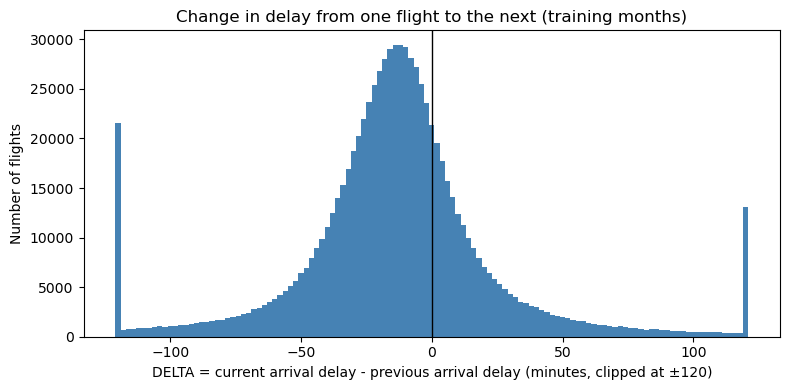

In [23]:
# E2 — How does the change in delay (DELTA) look in the training months?
print(train["DELTA"].describe(percentiles=[.05, .10, .25, .50, .75, .90, .95]).round(1).to_string())
print(f"\nShare arriving < 15 min late (delay fully removed): {(train['ARR_DELAY'] < 15).mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train["DELTA"].clip(-120, 120), bins=np.arange(-121, 122, 2), color="steelblue")   # 2-minute bins aligned to whole minutes
ax.axvline(0, color="black", lw=1)                                           # 0 = delay unchanged
ax.set_xlabel("DELTA = current arrival delay - previous arrival delay (minutes, clipped at ±120)")
ax.set_ylabel("Number of flights")
ax.set_title("Change in delay from one flight to the next (training months)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "delta_distribution.png"), dpi=300)       # save for the report
plt.show()

In [24]:
# E3 — Target rule, and class balance for several candidate thresholds (training months only)
CLASSES = ["Recovered", "Persistent", "Amplified"]


def make_target(df, T):
    recovered = (df["ARR_DELAY"] < 15) | (df["DELTA"] <= -T)      # delay removed, or reduced by T+ minutes
    amplified = df["DELTA"] >= T                                   # delay grew by T+ minutes
    labels = np.select([recovered, amplified], ["Recovered", "Amplified"], default="Persistent")
    return pd.Series(labels, index=df.index)                       # everything in between = Persistent


rows = []
for T in [10, 15, 20, 30]:                                         # candidate thresholds in minutes
    shares = make_target(train, T).value_counts(normalize=True) * 100
    rows.append({"threshold_min": T, **{c: round(shares.get(c, 0), 1) for c in CLASSES}})

balance = pd.DataFrame(rows)                                       # % of flights in each class
balance.to_csv(os.path.join(TABLES_DIR, "threshold_balance.csv"), index=False)
balance

,threshold_min,Recovered,Persistent,Amplified
0,10,60.8,21.4,17.8
1,15,55.2,30.2,14.6
2,20,50.6,37.3,12.1
3,30,44.5,46.8,8.7


In [25]:
# E4 — Fix the threshold and create the TARGET for every flight (train and test)
T = 15                                                             # chosen threshold in minutes (see E3)

data["TARGET"] = pd.Categorical(make_target(data, T), categories=CLASSES)    # the 3 classes
train = data[data["SPLIT"] == "train"]                                         # refresh the training view

counts = pd.crosstab(data["TARGET"], data["SPLIT"])                            # flights per class and split
shares = pd.crosstab(data["TARGET"], data["SPLIT"], normalize="columns").mul(100).round(1)
class_table = counts.join(shares, lsuffix="_n", rsuffix="_%")
class_table.to_csv(os.path.join(TABLES_DIR, "class_distribution.csv"))
class_table

SPLIT,test_n,train_n,test_%,train_%
TARGET,,,,
Recovered,94961,458367,53.2,55.2
Persistent,55337,251009,31.0,30.2
Amplified,28157,120823,15.8,14.6


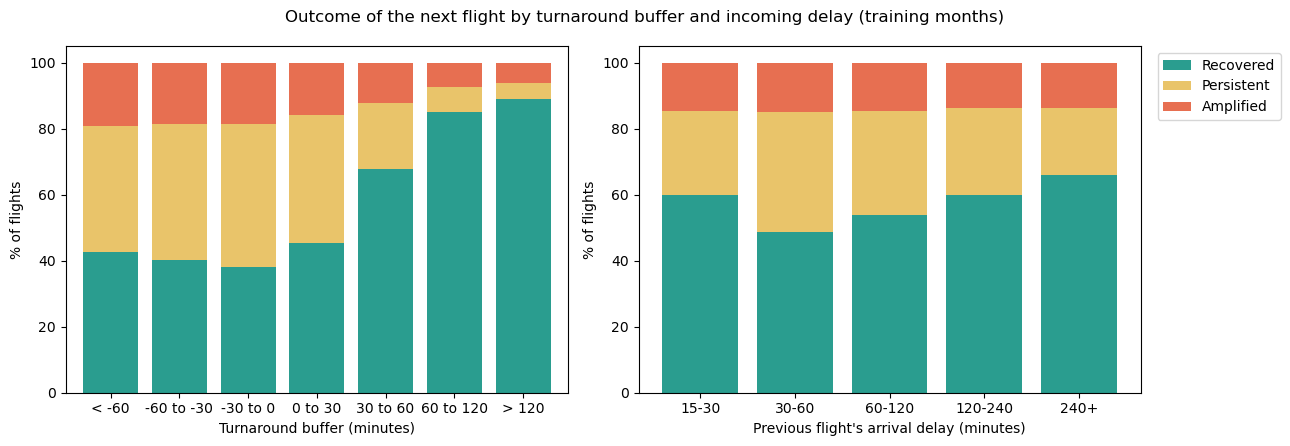

Median of key features per class (training months):
            PREV_ARR_DELAY  SCHED_TURN  TURN_BUFFER  PREV_DELAY_CHANGE  LEG_OF_DAY  ORIGIN_SCHED_DEPS
TARGET                                                                                               
Recovered             38.0        69.0         31.0                1.0         4.0               21.0
Persistent            40.0        50.0          8.0                1.0         4.0               16.0
Amplified             39.0        51.0         11.0                6.0         4.0               19.0


In [26]:
# E5 — How do turnaround buffer and incoming delay relate to the outcome? (training months)
COLORS = ["#2a9d8f", "#e9c46a", "#e76f51"]                         # Recovered, Persistent, Amplified


def class_shares_by(df, col, bins, labels):
    groups = pd.cut(df[col], bins=bins, labels=labels, right=False)               # put each flight in a bin
    return pd.crosstab(groups, df["TARGET"], normalize="index")[CLASSES] * 100   # % of each class per bin


panels = [
    ("TURN_BUFFER", [-np.inf, -60, -30, 0, 30, 60, 120, np.inf],
     ["< -60", "-60 to -30", "-30 to 0", "0 to 30", "30 to 60", "60 to 120", "> 120"],
     "Turnaround buffer (minutes)"),
    ("PREV_ARR_DELAY", [15, 30, 60, 120, 240, np.inf],
     ["15-30", "30-60", "60-120", "120-240", "240+"],
     "Previous flight's arrival delay (minutes)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (col, bins, labels, xlabel) in zip(axes, panels):
    class_shares_by(train, col, bins, labels).plot(kind="bar", stacked=True, ax=ax,
                                                   color=COLORS, width=0.8, legend=False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("% of flights")
    ax.tick_params(axis="x", rotation=0)
axes[1].legend(CLASSES, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Outcome of the next flight by turnaround buffer and incoming delay (training months)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "class_by_buffer_and_delay.png"), dpi=300)
plt.show()

key = ["PREV_ARR_DELAY", "SCHED_TURN", "TURN_BUFFER", "PREV_DELAY_CHANGE", "LEG_OF_DAY", "ORIGIN_SCHED_DEPS"]
print("Median of key features per class (training months):")
print(train.groupby("TARGET", observed=True)[key].median().round(1).to_string())

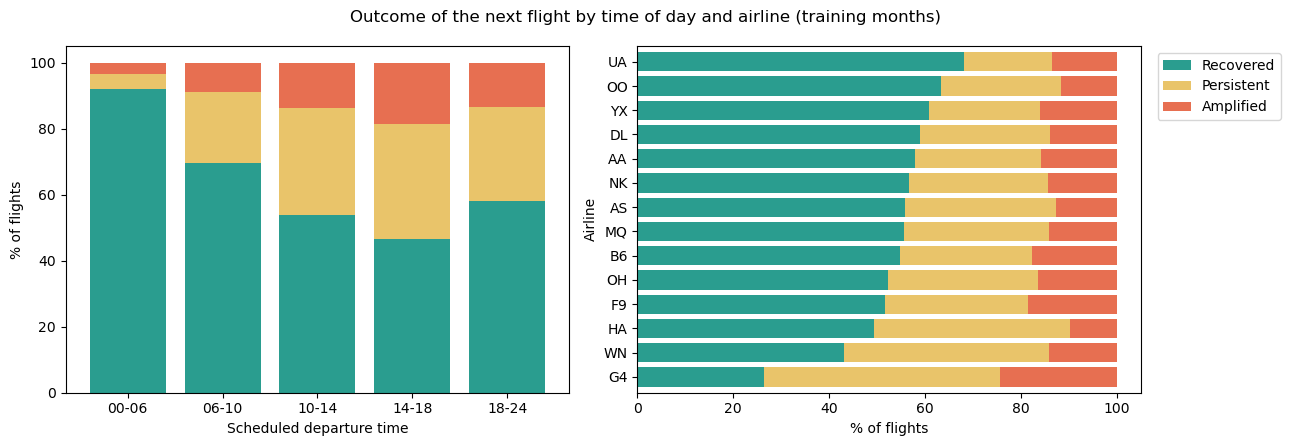

TARGET             flights  Recovered  Persistent  Amplified
OP_UNIQUE_CARRIER                                           
G4                   16997       26.5        49.2       24.4
WN                  171842       43.0        42.8       14.1
HA                    7011       49.4        41.0        9.7
F9                   32326       51.8        29.8       18.4
OH                   37812       52.2        31.4       16.4
B6                   27347       54.7        27.6       17.7
MQ                   37431       55.6        30.3       14.1
AS                   31541       55.7        31.7       12.6
NK                   23118       56.8        28.9       14.4
AA                  122180       57.9        26.3       15.8
DL                  105027       59.0        27.1       13.9
YX                   37595       60.8        23.2       16.0
OO                  101299       63.4        25.1       11.5
UA                   78673       68.2        18.3       13.4


In [27]:
# E6 — Does the outcome differ by time of day and by airline? (training months)
hour_shares = class_shares_by(train, "DEP_HOUR", [0, 6, 10, 14, 18, 24],
                              ["00-06", "06-10", "10-14", "14-18", "18-24"])

carrier = train["OP_UNIQUE_CARRIER"].astype(str)                                # airline code as plain text
carrier_shares = pd.crosstab(carrier, train["TARGET"], normalize="index")[CLASSES] * 100
carrier_shares = carrier_shares.sort_values("Recovered")                        # order by recovery rate
carrier_shares.insert(0, "flights", carrier.value_counts())                     # sample size per airline
carrier_shares.round(1).to_csv(os.path.join(TABLES_DIR, "class_by_carrier.csv"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
hour_shares.plot(kind="bar", stacked=True, ax=axes[0], color=COLORS, width=0.8, legend=False)
axes[0].set_xlabel("Scheduled departure time")
axes[0].set_ylabel("% of flights")
axes[0].tick_params(axis="x", rotation=0)
carrier_shares[CLASSES].plot(kind="barh", stacked=True, ax=axes[1], color=COLORS, width=0.8)
axes[1].set_xlabel("% of flights")
axes[1].set_ylabel("Airline")
axes[1].legend(CLASSES, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Outcome of the next flight by time of day and airline (training months)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "class_by_hour_and_airline.png"), dpi=300)
plt.show()

print(carrier_shares.round(1).to_string())

In [28]:
# E7 — Save the modelling checkpoint (features + TARGET + SPLIT)
out_path = os.path.join(PROCESSED_DIR, "model_data_2025.parquet")
data.to_parquet(out_path, index=False)
print(f"Saved {len(data):,} rows to {out_path}")

Saved 1,008,654 rows to data/processed/model_data_2025.parquet


# 4. MODEL

**What this section does:** trains and compares four models (Multinomial Logistic Regression, Decision Tree, Random Forest, Support Vector Machine) against two simple baselines, tunes each model with month-grouped cross-validation on the training months, and evaluates every model once on the unseen test months (Nov–Dec).

**Why:** macro-F1 is the main metric because the classes are imbalanced; class weights, month-grouped cross-validation, a single final test evaluation, and day-level bootstrap confidence intervals keep the comparison fair, honest and reproducible.

In [29]:
# M1 — Setup: libraries, load the modelling data, define the feature groups, split train/test
import time
import joblib                                                             # save fitted models to disk
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, ConfusionMatrixDisplay)

SEED = 42                                                                 # same random results every run
MODELS_DIR = "outputs/models"
os.makedirs(MODELS_DIR, exist_ok=True)
CLASSES = ["Recovered", "Persistent", "Amplified"]

data = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_data_2025.parquet"))   # checkpoint from EXPLORE

CAUSES = ["PREV_CARRIER_DELAY", "PREV_WEATHER_DELAY", "PREV_NAS_DELAY",
          "PREV_SECURITY_DELAY", "PREV_LATE_AIRCRAFT_DELAY"]
NUMERIC = ["PREV_ARR_DELAY", "PREV_DEP_DELAY", "PREV_DELAY_CHANGE", "PREV_TAXI_OUT", "PREV_TAXI_IN",
           *CAUSES, "SCHED_TURN", "TURN_BUFFER", "LEG_OF_DAY", "DISTANCE", "CRS_ELAPSED_TIME",
           "ORIGIN_SCHED_DEPS"]
TIME = ["DEP_HOUR", "DAY_OF_WEEK"]
CATEGORICAL = ["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]
# MONTH is NOT a feature: the test months (Nov-Dec) never appear in training, so it cannot be learned

# Exact identities between features (a problem only for the linear models)
cause_gap = (data[CAUSES].sum(axis=1) - data["PREV_ARR_DELAY"]).abs()
print(f"Delay causes add up exactly to PREV_ARR_DELAY: {(cause_gap < 1).mean():.1%} of flights")
LINEAR_NUMERIC = [c for c in NUMERIC                                      # linear models: drop 3 columns that are
                  if c not in ["SCHED_TURN", "PREV_DEP_DELAY",            # exact sums of others (no information lost)
                               "PREV_LATE_AIRCRAFT_DELAY"]]

train = data[data["SPLIT"] == "train"].reset_index(drop=True)            # Jan-Oct
test = data[data["SPLIT"] == "test"].reset_index(drop=True)              # Nov-Dec (unseen until the final evaluation)
X_train, y_train = train[NUMERIC + TIME + CATEGORICAL], train["TARGET"].astype(str)
X_test, y_test = test[NUMERIC + TIME + CATEGORICAL], test["TARGET"].astype(str)
groups_train = train["MONTH"]                                            # month of each training flight (for CV)
print(f"Training flights: {len(X_train):,}   Test flights: {len(X_test):,}   Features: {X_train.shape[1]}")

Delay causes add up exactly to PREV_ARR_DELAY: 100.0% of flights
Training flights: 830,199   Test flights: 178,455   Features: 21


In [30]:
# M2 — Preprocessing: one version for the linear models, one for the tree models
def make_preprocessor(kind):
    if kind == "linear":                                                  # Logistic Regression and SVM
        return ColumnTransformer([
            ("num", StandardScaler(), LINEAR_NUMERIC),                    # same scale for every numeric feature
            ("cat", OneHotEncoder(max_categories=31,                      # top 30 airports/airlines + "other"
                                  handle_unknown="infrequent_if_exist"),
             CATEGORICAL + TIME),                                         # hour and weekday as categories
        ])
    return ColumnTransformer([                                            # Decision Tree and Random Forest
        ("num", "passthrough", NUMERIC + TIME),                           # trees do not need scaling
        ("cat", OneHotEncoder(max_categories=31, handle_unknown="infrequent_if_exist",
                              sparse_output=False), CATEGORICAL),
    ], sparse_threshold=0)


print(make_preprocessor("linear").fit(X_train.head(50_000)).get_feature_names_out().shape[0], "columns (linear)")
print(make_preprocessor("tree").fit(X_train.head(50_000)).get_feature_names_out().shape[0], "columns (tree)")

109 columns (linear)
86 columns (tree)


In [31]:
# M3 — Helper functions: class scores, evaluation on the test set, tuning with cross-validation
results, predictions, models = {}, {}, {}                                 # filled in by the functions below


def class_scores(model, X):
    raw = model.predict_proba(X) if hasattr(model, "predict_proba") else model.decision_function(X)
    order = [list(model.classes_).index(c) for c in CLASSES]             # columns in Recovered/Persistent/Amplified order
    return raw[:, order]


def evaluate(name, y_pred, scores=None, cv_mean=np.nan, cv_std=np.nan, fit_seconds=np.nan):
    y_pred = np.asarray(y_pred)
    row = {"accuracy": accuracy_score(y_test, y_pred),
           "macro_precision": precision_score(y_test, y_pred, labels=CLASSES, average="macro", zero_division=0),
           "macro_recall": recall_score(y_test, y_pred, labels=CLASSES, average="macro", zero_division=0),
           "macro_f1": f1_score(y_test, y_pred, labels=CLASSES, average="macro", zero_division=0)}
    for c, f in zip(CLASSES, f1_score(y_test, y_pred, labels=CLASSES, average=None, zero_division=0)):
        row[f"f1_{c}"] = f                                                 # F1 of each class
    row["roc_auc_ovr"] = (np.nan if scores is None else                   # one-vs-rest AUC, averaged over classes
                          np.mean([roc_auc_score(y_test == c, scores[:, i]) for i, c in enumerate(CLASSES)]))
    row.update(cv_macro_f1_mean=cv_mean, cv_macro_f1_std=cv_std, fit_seconds=fit_seconds)
    results[name], predictions[name] = row, y_pred                         # store for the results table
    print(f"\n{name}: macro-F1 = {row['macro_f1']:.3f}   accuracy = {row['accuracy']:.3f}   "
          f"ROC-AUC = {row['roc_auc_ovr']:.3f}")
    print(classification_report(y_test, y_pred, labels=CLASSES, digits=3, zero_division=0))


cv = GroupKFold(n_splits=5)                                               # each fold holds out 2 whole months


def tune(name, pipeline, grid, X, y, groups):
    search = GridSearchCV(pipeline, grid, scoring="f1_macro", cv=cv, n_jobs=-1, refit=False)
    t0 = time.time()
    search.fit(X, y, groups=groups)                                       # try every setting in the grid
    best = search.best_index_
    mean, std = search.cv_results_["mean_test_score"][best], search.cv_results_["std_test_score"][best]
    print(f"{name}: best {search.best_params_}   CV macro-F1 = {mean:.3f} ± {std:.3f}   ({time.time() - t0:.0f}s)")
    cv_table = pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
    cv_table.to_csv(os.path.join(TABLES_DIR, f"cv_{name.lower().replace(' ', '_')}.csv"), index=False)
    return search.best_params_, mean, std


def fit_and_evaluate(name, pipeline, params, X, y, cv_mean, cv_std):
    pipeline.set_params(**params)                                          # use the best settings from CV
    t0 = time.time()
    pipeline.fit(X, y)                                                     # train on the training data
    seconds = time.time() - t0
    evaluate(name, pipeline.predict(X_test), class_scores(pipeline, X_test), cv_mean, cv_std, seconds)
    models[name] = pipeline
    joblib.dump(pipeline, os.path.join(MODELS_DIR, f"{name.lower().replace(' ', '_')}.joblib"), compress=3)
    print(f"Trained in {seconds:.0f}s and saved.")

In [32]:
# M4 — Baselines: what can be achieved WITHOUT machine learning?
majority = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)    # always predicts the commonest class
evaluate("Baseline: majority class", majority.predict(X_test), class_scores(majority, X_test))

BUFFER_BINS = [-np.inf, -60, -30, 0, 30, 60, 120, np.inf]                     # same bins as the EXPLORE chart
train_bins = pd.cut(train["TURN_BUFFER"], BUFFER_BINS, right=False)
rule = y_train.groupby(train_bins, observed=True).agg(lambda s: s.value_counts().idxmax())   # commonest class per bin
print("Buffer rule learned from training months:")
print(rule.to_string())
rule_pred = pd.cut(test["TURN_BUFFER"], BUFFER_BINS, right=False).map(rule).astype(str)
evaluate("Baseline: buffer rule", rule_pred)


Baseline: majority class: macro-F1 = 0.232   accuracy = 0.532   ROC-AUC = 0.500
              precision    recall  f1-score   support

   Recovered      0.532     1.000     0.695     94961
  Persistent      0.000     0.000     0.000     55337
   Amplified      0.000     0.000     0.000     28157

    accuracy                          0.532    178455
   macro avg      0.177     0.333     0.232    178455
weighted avg      0.283     0.532     0.370    178455

Buffer rule learned from training months:
TURN_BUFFER
[-inf, -60.0)      Recovered
[-60.0, -30.0)    Persistent
[-30.0, 0.0)      Persistent
[0.0, 30.0)        Recovered
[30.0, 60.0)       Recovered
[60.0, 120.0)      Recovered
[120.0, inf)       Recovered

Baseline: buffer rule: macro-F1 = 0.347   accuracy = 0.545   ROC-AUC = nan
              precision    recall  f1-score   support

   Recovered      0.578     0.849     0.687     94961
  Persistent      0.428     0.301     0.353     55337
   Amplified      0.000     0.000     0.00

In [33]:
# M5 — Tuning sample: a stratified sample of the training months for cross-validation
TUNE_N = min(200_000, len(train))                                          # rows used for tuning
tune_idx = (train.groupby("TARGET", observed=True)                          # same class mix as the full training set
                 .sample(frac=TUNE_N / len(train), random_state=SEED).index)
X_tune, y_tune, g_tune = X_train.loc[tune_idx], y_train.loc[tune_idx], groups_train.loc[tune_idx]
print(f"Tuning sample: {len(X_tune):,} flights from {g_tune.nunique()} months")
print(y_tune.value_counts(normalize=True).round(3).to_string())

Tuning sample: 200,000 flights from 10 months
TARGET
Recovered     0.552
Persistent    0.302
Amplified     0.146


In [34]:
# M6 — Model 1: Multinomial Logistic Regression
lr = Pipeline([("prep", make_preprocessor("linear")),
               ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED))])
lr_grid = {"clf__C": [0.01, 0.1, 1.0]}                                     # C = 1 / strength of regularisation
best, m, s = tune("Logistic Regression", lr, lr_grid, X_tune, y_tune, g_tune)
fit_and_evaluate("Logistic Regression", lr, best, X_train, y_train, m, s)

Logistic Regression: best {'clf__C': 0.1}   CV macro-F1 = 0.480 ± 0.008   (25s)

Logistic Regression: macro-F1 = 0.483   accuracy = 0.521   ROC-AUC = 0.710
              precision    recall  f1-score   support

   Recovered      0.775     0.544     0.639     94961
  Persistent      0.471     0.525     0.497     55337
   Amplified      0.245     0.437     0.314     28157

    accuracy                          0.521    178455
   macro avg      0.497     0.502     0.483    178455
weighted avg      0.597     0.521     0.544    178455

Trained in 28s and saved.


In [35]:
# M7 — Model 2: Decision Tree
dt = Pipeline([("prep", make_preprocessor("tree")),
               ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=SEED))])
dt_grid = {"clf__max_depth": [4, 6, 8, 12, 16],                            # how many questions deep
           "clf__min_samples_leaf": [100, 500]}                            # smallest group at the end of a branch
best, m, s = tune("Decision Tree", dt, dt_grid, X_tune, y_tune, g_tune)
fit_and_evaluate("Decision Tree", dt, best, X_train, y_train, m, s)

Decision Tree: best {'clf__max_depth': 12, 'clf__min_samples_leaf': 500}   CV macro-F1 = 0.495 ± 0.006   (46s)

Decision Tree: macro-F1 = 0.506   accuracy = 0.564   ROC-AUC = 0.729
              precision    recall  f1-score   support

   Recovered      0.777     0.618     0.689     94961
  Persistent      0.486     0.584     0.531     55337
   Amplified      0.264     0.342     0.298     28157

    accuracy                          0.564    178455
   macro avg      0.509     0.515     0.506    178455
weighted avg      0.606     0.564     0.578    178455

Trained in 18s and saved.


In [36]:
# M8 — Model 3: Random Forest (this cell takes the longest)
rf = Pipeline([("prep", make_preprocessor("tree")),
               ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                              random_state=SEED, n_jobs=1))])
rf_grid = {"clf__max_depth": [10, 16],
           "clf__min_samples_leaf": [50, 200]}
best, m, s = tune("Random Forest", rf, rf_grid, X_tune, y_tune, g_tune)
best["clf__n_jobs"] = -1                                                   # use all CPU cores for the final fit
fit_and_evaluate("Random Forest", rf, best, X_train, y_train, m, s)

Random Forest: best {'clf__max_depth': 16, 'clf__min_samples_leaf': 50}   CV macro-F1 = 0.511 ± 0.004   (125s)

Random Forest: macro-F1 = 0.516   accuracy = 0.565   ROC-AUC = 0.745
              precision    recall  f1-score   support

   Recovered      0.794     0.602     0.685     94961
  Persistent      0.488     0.586     0.532     55337
   Amplified      0.281     0.399     0.330     28157

    accuracy                          0.565    178455
   macro avg      0.521     0.529     0.516    178455
weighted avg      0.618     0.565     0.581    178455

Trained in 49s and saved.


In [37]:
# M9 — Model 4: Support Vector Machine (linear on all data + RBF kernel on a sample)
lsvm = Pipeline([("prep", make_preprocessor("linear")),
                 ("clf", LinearSVC(class_weight="balanced", max_iter=5000, random_state=SEED))])
lsvm_grid = {"clf__C": [0.01, 0.1, 1.0]}
best, m, s = tune("Linear SVM", lsvm, lsvm_grid, X_tune, y_tune, g_tune)
fit_and_evaluate("Linear SVM", lsvm, best, X_train, y_train, m, s)

SVM_N = min(20_000, len(train))                                             # kernel SVM cannot handle 830k rows
svm_idx = (train.groupby("TARGET", observed=True)
                .sample(frac=SVM_N / len(train), random_state=SEED).index)
X_svm, y_svm, g_svm = X_train.loc[svm_idx], y_train.loc[svm_idx], groups_train.loc[svm_idx]
rsvm = Pipeline([("prep", make_preprocessor("linear")),
                 ("clf", SVC(kernel="rbf", gamma="scale", class_weight="balanced", random_state=SEED))])
rsvm_grid = {"clf__C": [1.0, 10.0]}
best, m, s = tune("RBF SVM", rsvm, rsvm_grid, X_svm, y_svm, g_svm)
fit_and_evaluate("RBF SVM", rsvm, best, X_svm, y_svm, m, s)

Linear SVM: best {'clf__C': 0.1}   CV macro-F1 = 0.487 ± 0.006   (33s)

Linear SVM: macro-F1 = 0.487   accuracy = 0.581   ROC-AUC = 0.716
              precision    recall  f1-score   support

   Recovered      0.705     0.707     0.706     94961
  Persistent      0.482     0.559     0.518     55337
   Amplified      0.296     0.201     0.239     28157

    accuracy                          0.581    178455
   macro avg      0.494     0.489     0.487    178455
weighted avg      0.571     0.581     0.574    178455

Trained in 41s and saved.
RBF SVM: best {'clf__C': 1.0}   CV macro-F1 = 0.489 ± 0.007   (98s)

RBF SVM: macro-F1 = 0.491   accuracy = 0.534   ROC-AUC = 0.705
              precision    recall  f1-score   support

   Recovered      0.778     0.574     0.661     94961
  Persistent      0.464     0.521     0.491     55337
   Amplified      0.258     0.423     0.320     28157

    accuracy                          0.534    178455
   macro avg      0.500     0.506     0.491    1784

In [38]:
# M10 — Results table + 95% confidence intervals (bootstrap over test DAYS)
results_df = pd.DataFrame(results).T                                        # one row per model

y_true_codes = y_test.map({c: i for i, c in enumerate(CLASSES)}).to_numpy()  # classes as 0/1/2 (fast)


def macro_f1_codes(t, p):
    cm = np.bincount(t * 3 + p, minlength=9).reshape(3, 3)                  # confusion matrix
    tp = np.diag(cm)
    precision = tp / np.maximum(cm.sum(axis=0), 1)
    recall = tp / np.maximum(cm.sum(axis=1), 1)
    f1 = np.where(precision + recall > 0, 2 * precision * recall / np.maximum(precision + recall, 1e-12), 0)
    return f1.mean()


rng = np.random.default_rng(SEED)
rows_by_day = [np.flatnonzero(test["FL_DATE"].to_numpy() == d) for d in test["FL_DATE"].unique()]
B = 500                                                                     # number of bootstrap repeats
resamples = [np.concatenate([rows_by_day[k] for k in rng.integers(0, len(rows_by_day), len(rows_by_day))])
             for _ in range(B)]                                             # resample whole days, with replacement

for name, y_pred in predictions.items():
    p = pd.Series(y_pred).map({c: i for i, c in enumerate(CLASSES)}).fillna(0).astype(int).to_numpy()
    f1s = [macro_f1_codes(y_true_codes[r], p[r]) for r in resamples]
    results_df.loc[name, "macro_f1_ci_low"], results_df.loc[name, "macro_f1_ci_high"] = np.percentile(f1s, [2.5, 97.5])

results_df = results_df.astype(float).round(3).sort_values("macro_f1", ascending=False)
results_df.to_csv(os.path.join(TABLES_DIR, "model_results.csv"))
results_df[["macro_f1", "macro_f1_ci_low", "macro_f1_ci_high", "accuracy", "roc_auc_ovr",
            "f1_Recovered", "f1_Persistent", "f1_Amplified", "cv_macro_f1_mean", "cv_macro_f1_std", "fit_seconds"]]

,macro_f1,macro_f1_ci_low,macro_f1_ci_high,accuracy,roc_auc_ovr,f1_Recovered,f1_Persistent,f1_Amplified,cv_macro_f1_mean,cv_macro_f1_std,fit_seconds
Random Forest,0.516,0.506,0.523,0.565,0.745,0.685,0.532,0.330,0.511,0.004,48.520
Decision Tree,0.506,0.498,0.512,0.564,0.729,0.689,0.531,0.298,0.495,0.006,18.125
RBF SVM,0.491,0.481,0.499,0.534,0.705,0.661,0.491,0.320,0.489,0.007,33.679
Linear SVM,0.487,0.479,0.496,0.581,0.716,0.706,0.518,0.239,0.487,0.006,41.084
Logistic Regression,0.483,0.472,0.492,0.521,0.710,0.639,0.497,0.314,0.480,0.008,28.292
Baseline: buffer rule,0.347,0.341,0.353,0.545,NaN,0.687,0.353,0.000,NaN,NaN,NaN
Baseline: majority class,0.232,0.225,0.239,0.532,0.500,0.695,0.000,0.000,NaN,NaN,NaN


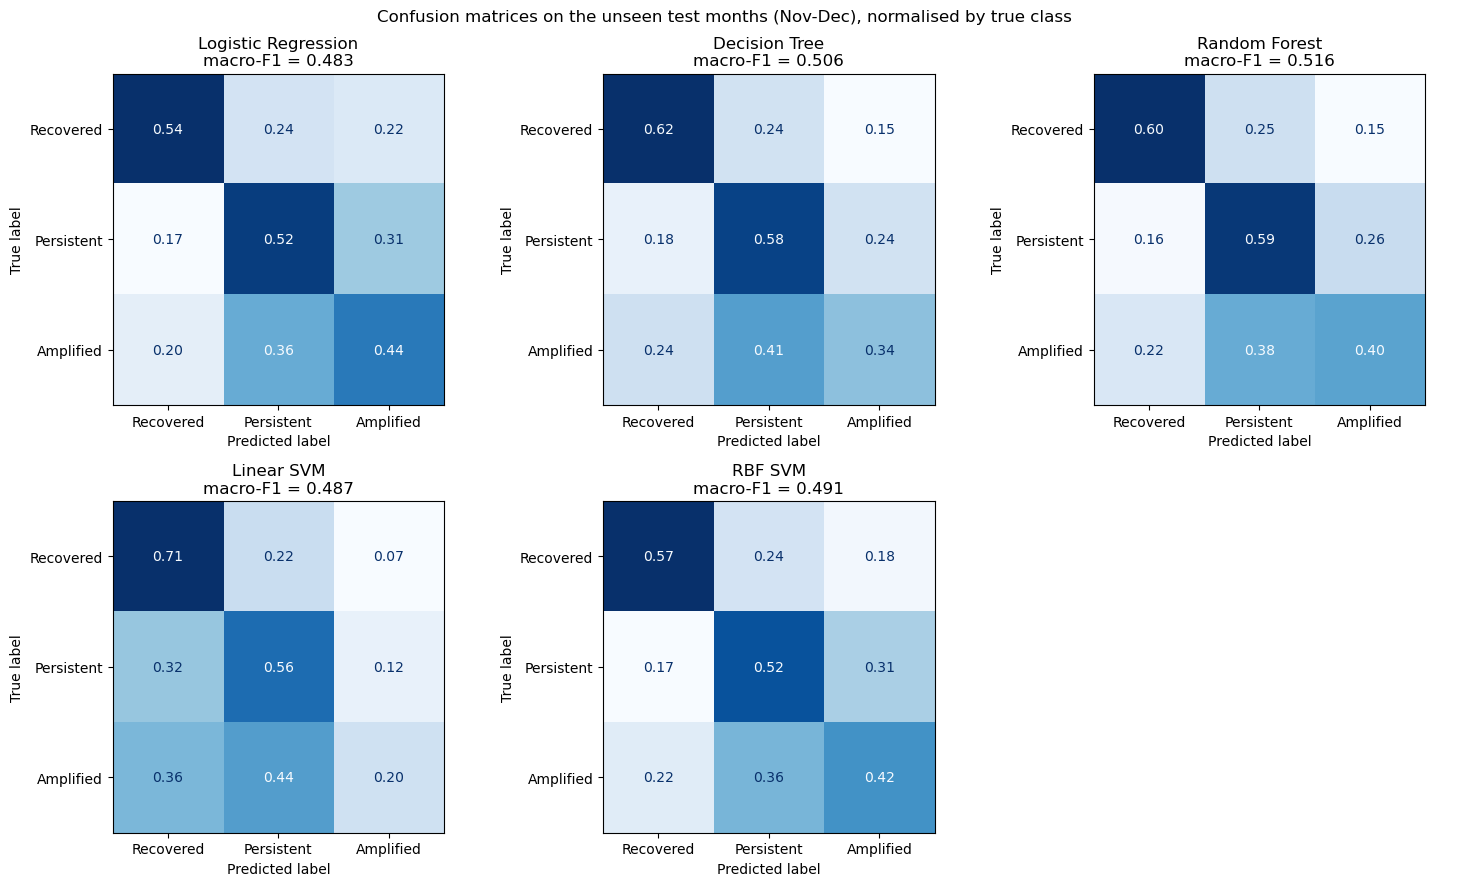

In [39]:
# M11 — Confusion matrices of the four models (rows = true class, shown as % of each true class)
ml_models = ["Logistic Regression", "Decision Tree", "Random Forest", "Linear SVM", "RBF SVM"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, name in zip(axes.ravel(), ml_models):
    ConfusionMatrixDisplay.from_predictions(y_test, predictions[name], labels=CLASSES, normalize="true",
                                            values_format=".2f", cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"{name}\nmacro-F1 = {results[name]['macro_f1']:.3f}")
axes.ravel()[-1].axis("off")                                                # empty 6th panel
fig.suptitle("Confusion matrices on the unseen test months (Nov-Dec), normalised by true class")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "confusion_matrices.png"), dpi=300)
plt.show()

# 5. INTERPRET

**What this section does:** explains what the models learned (Logistic Regression odds ratios, Decision Tree rules, Random Forest permutation importance), tests whether the best model is significantly better than the others (paired bootstrap), checks whether performance differs across airlines and times of day (fairness), and tests whether the results depend on the chosen threshold (sensitivity analysis).

**Why:** The project's aim is *explainable* prediction of delay propagation; these analyses turn model outputs into operational insight and test how robust the conclusions are.

In [40]:
# I1 — Make sure the trained models are in memory (loads them from disk if Jupyter was restarted)
from sklearn.tree import plot_tree, export_text
from sklearn.inspection import permutation_importance
from sklearn.base import clone

ML_MODELS = ["Logistic Regression", "Decision Tree", "Random Forest", "Linear SVM", "RBF SVM"]
for name in ML_MODELS:
    if name not in models:                                                   # only after a restart
        models[name] = joblib.load(os.path.join(MODELS_DIR, f"{name.lower().replace(' ', '_')}.joblib"))
        predictions[name] = models[name].predict(X_test)
print("Models available:", list(models))

Models available: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Linear SVM', 'RBF SVM']


Odds ratio for a 1-standard-deviation increase in each feature (1.0 = no effect):
                     Amplified vs Recovered  Persistent vs Recovered
TURN_BUFFER                            0.28                     0.16
PREV_ARR_DELAY                         0.37                     0.26
CRS_ELAPSED_TIME                       0.50                     0.32
PREV_TAXI_OUT                          0.93                     1.04
LEG_OF_DAY                             0.96                     0.99
PREV_SECURITY_DELAY                    1.00                     1.00
ORIGIN_SCHED_DEPS                      1.02                     1.02
PREV_CARRIER_DELAY                     1.03                     1.01
PREV_WEATHER_DELAY                     1.07                     1.02
PREV_TAXI_IN                           1.08                     1.08
PREV_NAS_DELAY                         1.13                     1.07
PREV_DELAY_CHANGE                      1.22                     1.00
DISTANCE             

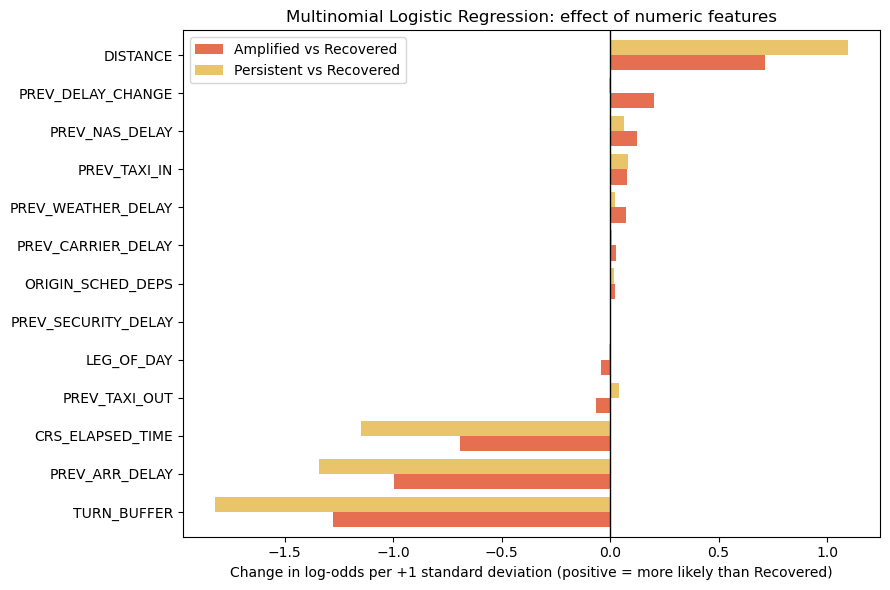

In [41]:
# I2 — Logistic Regression: how each feature changes the odds of Amplified / Persistent vs Recovered
lr_prep, lr_clf = models["Logistic Regression"].named_steps["prep"], models["Logistic Regression"].named_steps["clf"]
coef = pd.DataFrame(lr_clf.coef_, index=lr_clf.classes_, columns=lr_prep.get_feature_names_out())

contrast = pd.DataFrame({                                                    # log-odds difference vs Recovered
    "Amplified vs Recovered": coef.loc["Amplified"] - coef.loc["Recovered"],
    "Persistent vs Recovered": coef.loc["Persistent"] - coef.loc["Recovered"]})
numeric_part = contrast[contrast.index.str.startswith("num__")].copy()       # the numeric features only
numeric_part.index = numeric_part.index.str.replace("num__", "")
numeric_part = numeric_part.sort_values("Amplified vs Recovered")

odds_ratios = np.exp(numeric_part).round(2)                                  # odds ratio per +1 standard deviation
odds_ratios.to_csv(os.path.join(TABLES_DIR, "lr_odds_ratios.csv"))
print("Odds ratio for a 1-standard-deviation increase in each feature (1.0 = no effect):")
print(odds_ratios.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
numeric_part.plot(kind="barh", ax=ax, color=["#e76f51", "#e9c46a"], width=0.8)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Change in log-odds per +1 standard deviation (positive = more likely than Recovered)")
ax.set_title("Multinomial Logistic Regression: effect of numeric features")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "lr_coefficients.png"), dpi=300)
plt.show()

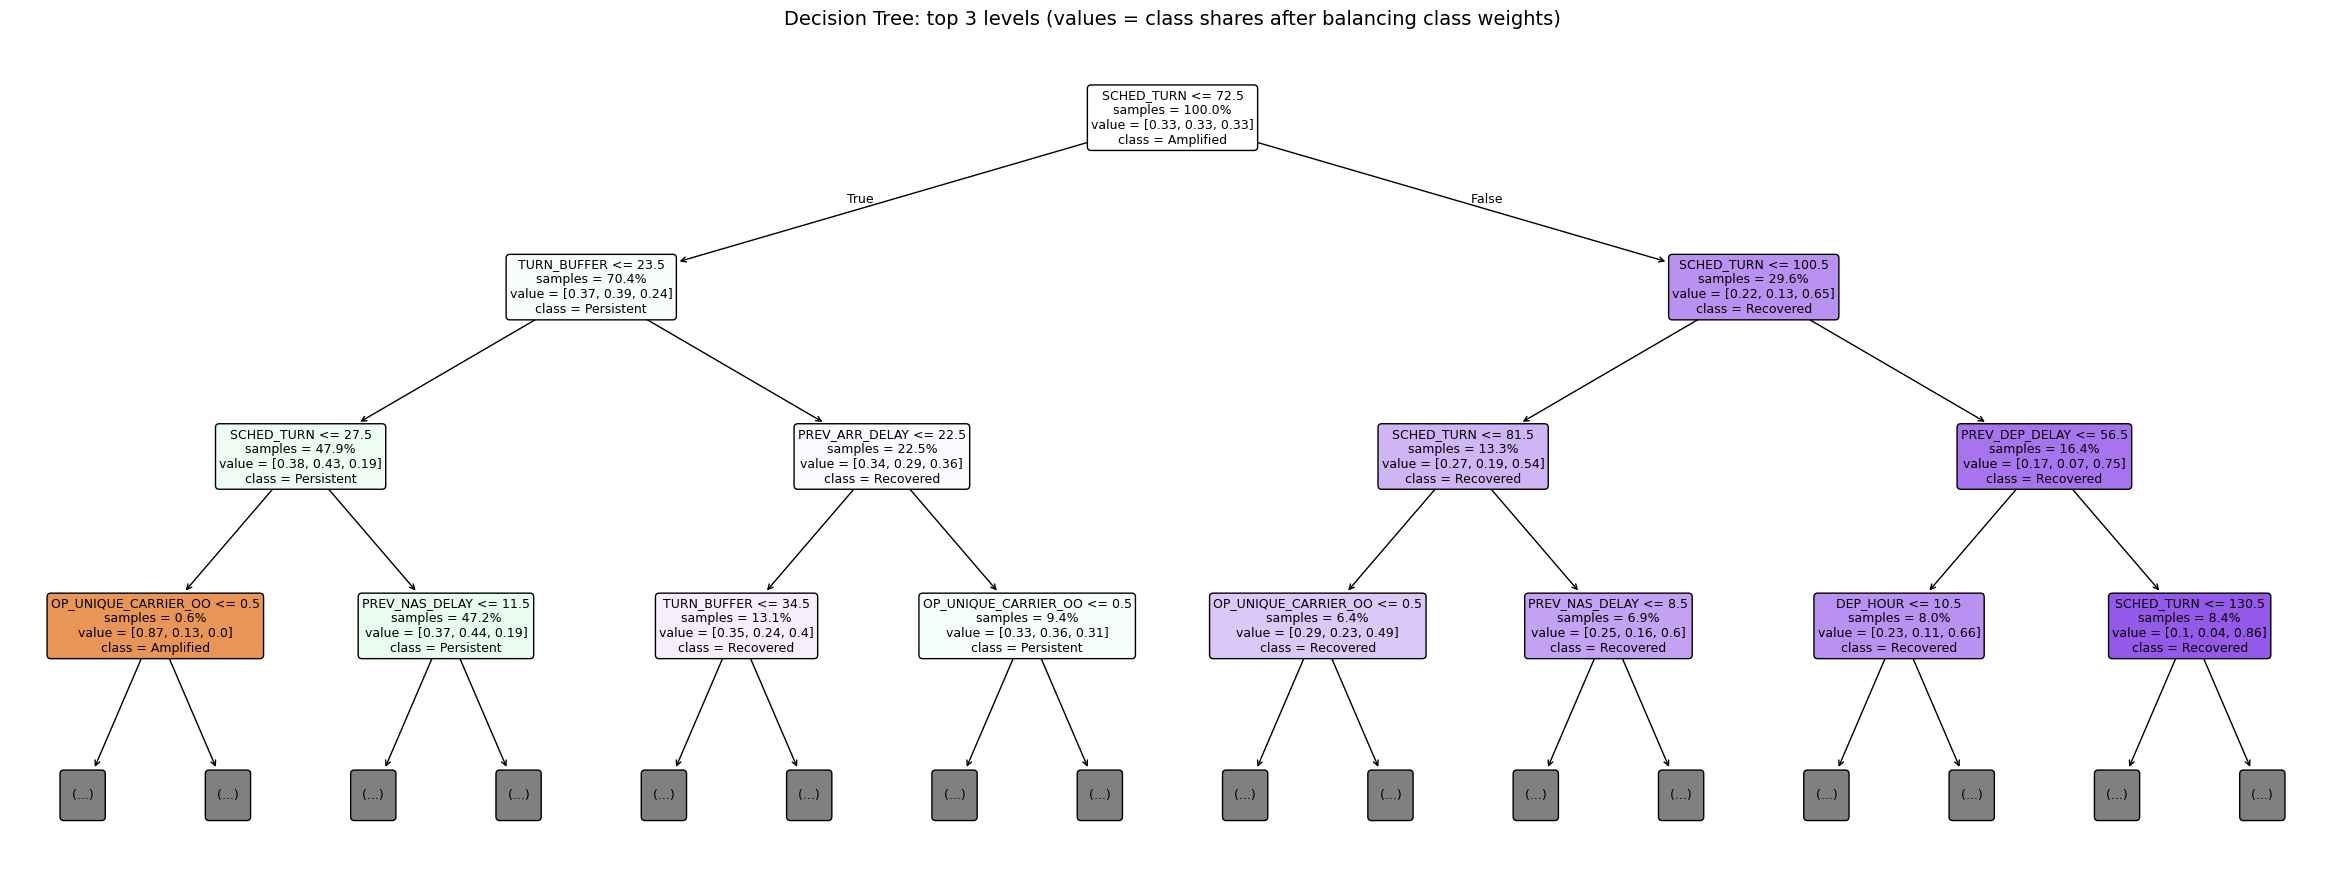

|--- SCHED_TURN <= 72
|   |--- TURN_BUFFER <= 24
|   |   |--- SCHED_TURN <= 28
|   |   |   |--- OP_UNIQUE_CARRIER_OO <= 0
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- OP_UNIQUE_CARRIER_OO >  0
|   |   |   |   |--- class: Amplified
|   |   |--- SCHED_TURN >  28
|   |   |   |--- PREV_NAS_DELAY <= 12
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- PREV_NAS_DELAY >  12
|   |   |   |   |--- truncated branch of depth 9
|   |--- TURN_BUFFER >  24
|   |   |--- PREV_ARR_DELAY <= 22
|   |   |   |--- TURN_BUFFER <= 34
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- TURN_BUFFER >  34
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- PREV_ARR_DELAY >  22
|   |   |   |--- OP_UNIQUE_CARRIER_OO <= 0
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- OP_UNIQUE_CARRIER_OO >  0
|   |   |   |   |--- truncated branch of depth 5
|--- SCHED_TURN >  72
|   |--- SCHED_TURN <= 100
|   |   |--- SCHED_TURN <= 82
|   |   |   |--- O

In [42]:
# I3 — Decision Tree: draw the top 3 levels and print them as rules
dt_prep, dt_clf = models["Decision Tree"].named_steps["prep"], models["Decision Tree"].named_steps["clf"]
dt_features = [n.split("__", 1)[1] for n in dt_prep.get_feature_names_out()]     # remove "num__" / "cat__"

fig, ax = plt.subplots(figsize=(30, 11))
plot_tree(dt_clf, max_depth=3, feature_names=dt_features, class_names=list(dt_clf.classes_),
          filled=True, rounded=True, impurity=False, proportion=True, precision=2, fontsize=9, ax=ax)
ax.set_title("Decision Tree: top 3 levels (values = class shares after balancing class weights)", fontsize=14)
fig.savefig(os.path.join(FIG_DIR, "decision_tree_top_levels.png"), dpi=200, bbox_inches="tight")
plt.show()

rules = export_text(dt_clf, feature_names=dt_features, max_depth=3, decimals=0)  # the same tree as text rules
with open(os.path.join(TABLES_DIR, "decision_tree_rules.txt"), "w") as f:
    f.write(rules)
print(rules)

Done in 16s


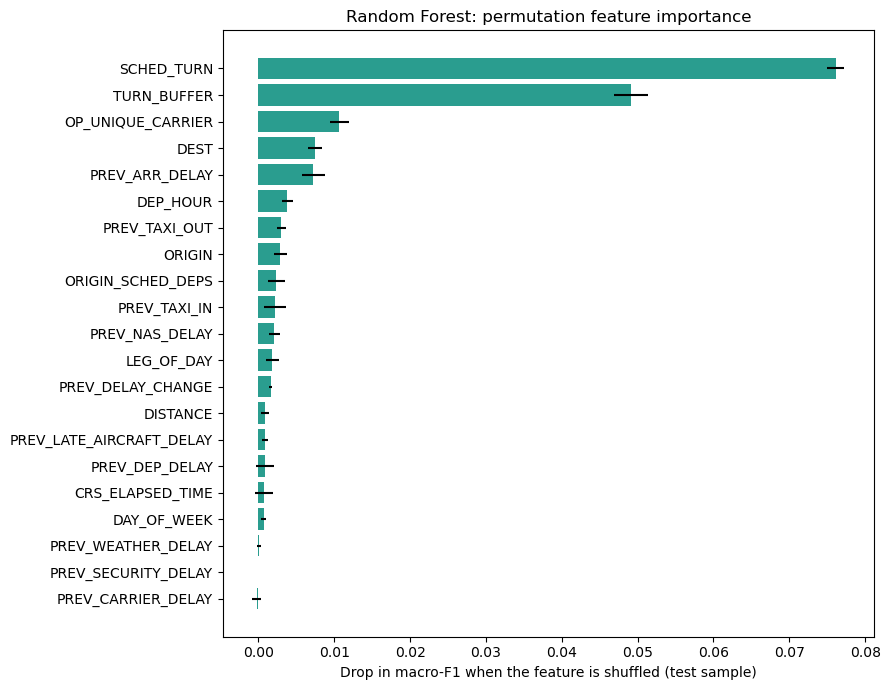

In [43]:
# I4 — Random Forest: permutation importance (how much macro-F1 drops when a feature is shuffled)
sample_idx = X_test.sample(n=min(20_000, len(X_test)), random_state=SEED).index      # test sample (for speed)
t0 = time.time()
perm = permutation_importance(models["Random Forest"], X_test.loc[sample_idx], y_test.loc[sample_idx],
                              scoring="f1_macro", n_repeats=5, random_state=SEED, n_jobs=1)
importance = (pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std},
                           index=X_test.columns)
                .sort_values("importance"))
importance.round(4).to_csv(os.path.join(TABLES_DIR, "rf_permutation_importance.csv"))
print(f"Done in {time.time() - t0:.0f}s")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance.index, importance["importance"], xerr=importance["std"], color="#2a9d8f")
ax.set_xlabel("Drop in macro-F1 when the feature is shuffled (test sample)")
ax.set_title("Random Forest: permutation feature importance")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "rf_permutation_importance.png"), dpi=300)
plt.show()

In [44]:
# I5 — Is the Random Forest really better? Paired bootstrap of the DIFFERENCE in macro-F1 (same resampled days)
CODES = {c: i for i, c in enumerate(CLASSES)}
rf_codes = pd.Series(predictions["Random Forest"]).map(CODES).astype(int).to_numpy()

rows = []
for name in ["Decision Tree", "RBF SVM", "Linear SVM", "Logistic Regression"]:
    other_codes = pd.Series(predictions[name]).map(CODES).astype(int).to_numpy()
    diffs = np.array([macro_f1_codes(y_true_codes[r], rf_codes[r]) - macro_f1_codes(y_true_codes[r], other_codes[r])
                      for r in resamples])                                   # RF minus the other model, per resample
    rows.append({"comparison": f"Random Forest - {name}", "mean_difference": diffs.mean(),
                 "ci_low": np.percentile(diffs, 2.5), "ci_high": np.percentile(diffs, 97.5),
                 "share_RF_better": (diffs > 0).mean()})
paired = pd.DataFrame(rows).set_index("comparison").round(4)
paired.to_csv(os.path.join(TABLES_DIR, "paired_bootstrap.csv"))
paired

,mean_difference,ci_low,ci_high,share_RF_better
comparison,,,,
Random Forest - Decision Tree,0.0097,0.0075,0.0119,1.0
Random Forest - RBF SVM,0.0249,0.0203,0.0294,1.0
Random Forest - Linear SVM,0.0281,0.0223,0.0351,1.0
Random Forest - Logistic Regression,0.0324,0.0279,0.0372,1.0


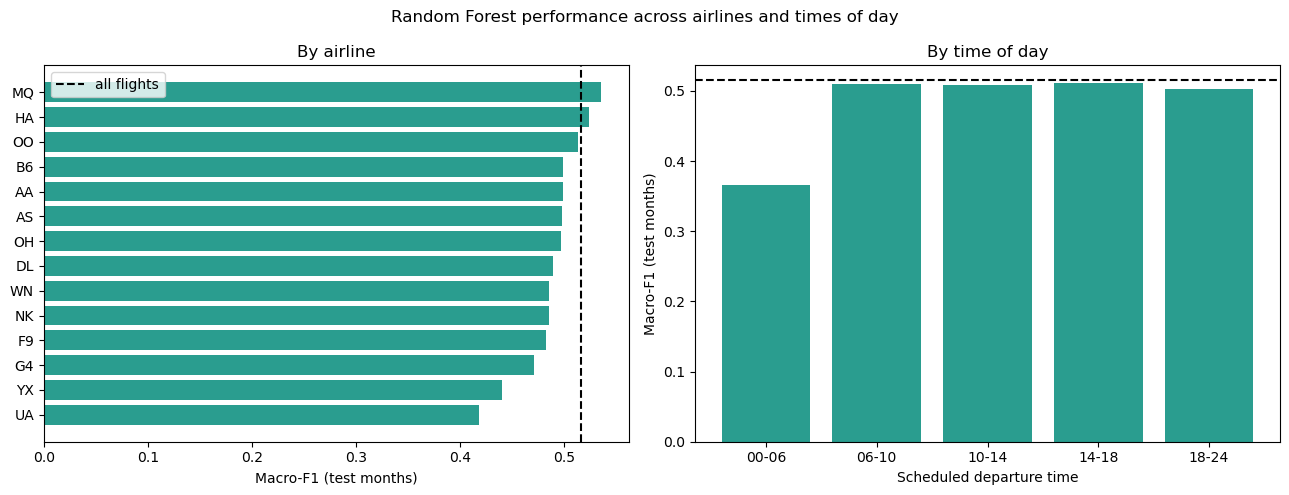

       flights  macro_f1  recall_Amplified
group                                     
UA       16612     0.418             0.484
YX       10947     0.440             0.585
G4        3617     0.471             0.522
F9        6537     0.482             0.480
NK        4061     0.485             0.457
WN       37435     0.485             0.180
DL       23141     0.489             0.415
OH        8658     0.497             0.403
AS        6415     0.498             0.343
AA       23111     0.499             0.474
B6        7065     0.499             0.486
OO       21576     0.513             0.354
HA        2010     0.524             0.051
MQ        7270     0.535             0.521

       flights  macro_f1  recall_Amplified
group                                     
00-06     4363     0.366             0.040
06-10    12826     0.510             0.314
10-14    42127     0.508             0.433
14-18    55750     0.511             0.448
18-24    63389     0.503             0.342


In [45]:
# I6 — Where does the Random Forest work well or badly? Error analysis by airline and time of day
rf_pred = pd.Series(predictions["Random Forest"], index=y_test.index)


def scores_by(groups):
    rows = []
    for g, idx in y_test.groupby(groups, observed=True).groups.items():
        rows.append({"group": g, "flights": len(idx),
                     "macro_f1": f1_score(y_test[idx], rf_pred[idx], labels=CLASSES, average="macro", zero_division=0),
                     "recall_Amplified": recall_score(y_test[idx], rf_pred[idx], labels=["Amplified"],
                                                      average="macro", zero_division=0)})
    return pd.DataFrame(rows).set_index("group").round(3)


by_carrier = scores_by(test["OP_UNIQUE_CARRIER"].astype(str)).sort_values("macro_f1")
by_hour = scores_by(pd.cut(test["DEP_HOUR"], [0, 6, 10, 14, 18, 24], right=False,
                           labels=["00-06", "06-10", "10-14", "14-18", "18-24"]))
by_carrier.to_csv(os.path.join(TABLES_DIR, "rf_scores_by_carrier.csv"))
by_hour.to_csv(os.path.join(TABLES_DIR, "rf_scores_by_hour.csv"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(by_carrier.index, by_carrier["macro_f1"], color="#2a9d8f")
axes[0].axvline(results["Random Forest"]["macro_f1"], color="black", ls="--", label="all flights")
axes[0].set_xlabel("Macro-F1 (test months)")
axes[0].set_title("By airline")
axes[0].legend()
axes[1].bar(by_hour.index.astype(str), by_hour["macro_f1"], color="#2a9d8f")
axes[1].axhline(results["Random Forest"]["macro_f1"], color="black", ls="--")
axes[1].set_xlabel("Scheduled departure time")
axes[1].set_ylabel("Macro-F1 (test months)")
axes[1].set_title("By time of day")
fig.suptitle("Random Forest performance across airlines and times of day")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "rf_scores_by_group.png"), dpi=300)
plt.show()
print(by_carrier.to_string())
print()
print(by_hour.to_string())

In [46]:
# I7 — Sensitivity analysis: does the conclusion hold for other thresholds T? (retrains the Random Forest)
def make_target(df, T):                                                      # same rule as in EXPLORE (E3)
    recovered = (df["ARR_DELAY"] < 15) | (df["DELTA"] <= -T)
    amplified = df["DELTA"] >= T
    return pd.Series(np.select([recovered, amplified], ["Recovered", "Amplified"], default="Persistent"),
                     index=df.index)


sens_rows = []
for T_alt in [10, 15, 20]:
    y_tr, y_te = make_target(train, T_alt), make_target(test, T_alt)        # targets with this threshold
    if T_alt == 15:
        pred = predictions["Random Forest"]                                  # already trained in MODEL
    else:
        t0 = time.time()
        pred = clone(models["Random Forest"]).fit(X_train, y_tr).predict(X_test)   # same settings, new target
        print(f"T = {T_alt}: retrained in {time.time() - t0:.0f}s")
    majority_pred = np.full(len(y_te), y_tr.value_counts().idxmax())
    sens_rows.append({"threshold_min": T_alt,
                      "pct_Amplified_test": round((y_te == "Amplified").mean() * 100, 1),
                      "rf_macro_f1": f1_score(y_te, pred, labels=CLASSES, average="macro", zero_division=0),
                      "rf_f1_Amplified": f1_score(y_te, pred, labels=["Amplified"], average="macro", zero_division=0),
                      "majority_macro_f1": f1_score(y_te, majority_pred, labels=CLASSES, average="macro",
                                                    zero_division=0)})
sensitivity = pd.DataFrame(sens_rows).set_index("threshold_min").round(3)
sensitivity.to_csv(os.path.join(TABLES_DIR, "threshold_sensitivity.csv"))
sensitivity

T = 10: retrained in 51s
T = 20: retrained in 50s


,pct_Amplified_test,rf_macro_f1,rf_f1_Amplified,majority_macro_f1
threshold_min,,,,
10,19.4,0.485,0.365,0.247
15,15.8,0.516,0.330,0.232
20,13.0,0.537,0.301,0.218


In [47]:
# R1 — Save the exact library versions used, for reproducibility (creates requirements.txt)
import sys
import joblib
import matplotlib
import sklearn
try:
    import pyarrow as parquet_engine                    # library that reads/writes .parquet files
except ImportError:
    import fastparquet as parquet_engine

versions = {"numpy": np.__version__, "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
            "matplotlib": matplotlib.__version__, "joblib": joblib.__version__,
            parquet_engine.__name__: parquet_engine.__version__}
with open("requirements.txt", "w") as f:                # one line per library, e.g. pandas==2.3.3
    for package, version in versions.items():
        f.write(f"{package}=={version}\n")

print("Python", sys.version.split()[0])
print(open("requirements.txt").read())

Python 3.13.9
numpy==2.3.5
pandas==2.3.3
scikit-learn==1.7.2
matplotlib==3.10.6
joblib==1.5.2
pyarrow==21.0.0

